In [6]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
import json
import torch
import src.utils_contributions as utils_contributions
import pickle
from lm_saliency import *
from collections import defaultdict
import pandas as pd
import statistics

device = "cuda" if torch.cuda.is_available() else "cpu"

In [8]:
name_path = 'gpt2'
_, tokenizer = utils_contributions.load_model_tokenizer(name_path,only_tokenizer=True)
name_path = name_path.replace('/','-')

In [9]:
datasets = {'blimp': ['anaphor_gender_agreement',
            'anaphor_number_agreement',
            'animate_subject_passive',
            'determiner_noun_agreement_1',
            'determiner_noun_agreement_irregular_1',
            'determiner_noun_agreement_with_adjective_1',
            'determiner_noun_agreement_with_adj_irregular_1',
            'npi_present_1',
            'distractor_agreement_relational_noun'],
            'sva': ['sva_1', 'sva_2', 'sva_3', 'sva_4'],
            'ioi': ['ioi']}

In [10]:
from src.utils_evaluation import read_subset, read_attribution_scores, read_sentence_target_foil, tokenize_target_foil, get_ground_truth_tokens
from scipy.stats import rankdata

results_dict = {}
results_dict_raw = {}

metric = 'mrr'

only_fails = False
only_corrects = False

methods_list = ['erasure', 'ours', 'grad']
#methods_list = ['ours']


distance_subset = defaultdict(list)
for dataset in datasets.keys():#datasets.keys()
    for subset in datasets[dataset]:
        print(subset)
        # Read datasets from csv as DataFrames
        df, num_examples = read_subset(subset)
        results_method = {}
        results_method_raw = {}

        info_sentence_results_file = f'./results/{name_path}/{subset}_info_sentence.csv'
        # Read logits difference between target and foil
        df_logits_diff = pd.read_csv(info_sentence_results_file, delimiter='|')
        fail_examples = df_logits_diff[df_logits_diff['logit_diff']<0].index.tolist()
        correct_examples = df_logits_diff[df_logits_diff['logit_diff']>0].index.tolist()

        # Iterate over every method
        for idx_method, method in enumerate(methods_list):
            print('method', method)

            # Read json files with attribtuion scores
            explanations_dict = read_attribution_scores(name_path, dataset, subset, method)
            # Read pickle file with logits information
            with open(f'./results/logits/{subset}_{name_path}.pickle', 'rb') as handle:
                logits_file = pickle.load(handle)

            expla_type_results = {}
            expla_type_results_raw = defaultdict(list)
            # Initialize explanation types results to zero
            for expla_type in explanations_dict.keys():
                # if 'layerwise' in expla_type:
                #     continue
                # Make sure the total number of sentences with explanations in json
                # is equal to num_examples
                assert len(explanations_dict[expla_type]) == num_examples
                expla_type_results[expla_type] = 0
            # Initialize random baseline to zero
            if idx_method == len(methods_list)-1:
                # If last  method in list, compute random baseline
                expla_type_results['random'] = 0

            counter = 0

            #num_examples = 1
            for idx in range(num_examples):
                if only_fails == True:
                    if idx not in fail_examples:
                        continue
                elif only_fails == False and only_corrects == True:
                    if idx not in correct_examples:
                        continue
                    
                text, target, foil = read_sentence_target_foil(df, subset, idx)
                CORRECT_ID, FOIL_ID, min_length = tokenize_target_foil(name_path, tokenizer, target, foil)
                pt_batch = tokenizer(text, return_tensors="pt").to(device)
                tokenized_text = tokenizer.convert_ids_to_tokens(pt_batch["input_ids"][0])

                # If target and foil are the same continue
                if CORRECT_ID == FOIL_ID:
                    continue

                ground_truth_binary_vector, gt_token_pos = get_ground_truth_tokens(subset, text, target, tokenizer, df, idx)
                if ground_truth_binary_vector is None:
                    continue

                if logits_file[idx] == 'NA':
                    # Continue if seq_length > min_length
                    if len(tokenized_text)>min_length:
                        continue
                if idx_method == 0:
                    distance_subset[subset].append(len(tokenized_text) - gt_token_pos[-1])

                for expla_type in explanations_dict.keys():
                    # if 'layer' in expla_type:
                    #     continue
                    contribs_input_tok = np.asarray(explanations_dict[expla_type][idx])                
                    
                    if len(tokenized_text) == min_length:
                        # Add case where there is just one token before prediction (probes needed changes)
                        # if not considered
                        # We create an array of ones (opt requires </s>)
                        contribs_input_tok = np.ones(min_length)

                    # Normalize ours contributions
                    if 'logit' in expla_type:
                        if logits_file[idx] != 'NA':
                            # Add init logit diff
                            if 'layer' not in expla_type:
                                # Add embedding logit to last res stream
                                init_logits_diff = logits_file[idx]['init_logit'][0] - logits_file[idx]['init_logit'][1]
                                contribs_input_tok[-1] += init_logits_diff
                            #print(f'contribs_input_tok {expla_type} {contribs_input_tok}')
                            if metric is not 'dot_product':
                                norm = np.linalg.norm(contribs_input_tok, ord=1)
                                contribs_input_tok /= norm
                    if metric == 'dot_product':
                        # Dot-product alignment metric
                        expla_type_results[expla_type] += np.matmul(contribs_input_tok, ground_truth_binary_vector)
                        expla_type_results_raw[expla_type].append(np.matmul(contribs_input_tok, ground_truth_binary_vector))
                    elif metric == 'mrr':
                        # Mean Reciprocal Rank
                        rank_ascending = rankdata(contribs_input_tok, method='dense', axis = -1)
                        rank_descending = len(rank_ascending) - rank_ascending + 1
                        expla_type_results[expla_type] += 1/(min(rank_descending[gt_token_pos]))
                        
                    elif metric == 'probes':
                        # Probes Needed
                        rank_ascending = rankdata(contribs_input_tok, method='dense', axis = -1)
                        rank_descending = len(rank_ascending) - rank_ascending
                        expla_type_results[expla_type] += min(rank_descending[gt_token_pos])

                #Add random baseline
                if idx_method == len(methods_list)-1:
                    # If last method in list, compute random baseline
                    random_explanations = np.random.uniform(low=0.0, high=1.0, size=ground_truth_binary_vector.shape[0])
                    if metric == 'dot_product':
                        norm = np.linalg.norm(random_explanations, ord=1)
                        random_explanations /= norm
                        expla_type_results['random'] += np.matmul(random_explanations, ground_truth_binary_vector)
                    elif metric == 'mrr':
                        rank_ascending = rankdata(random_explanations, method='dense', axis = -1)
                        rank_descending = len(rank_ascending) - rank_ascending + 1
                        expla_type_results['random'] += 1/(min(rank_descending[gt_token_pos]))
                    elif metric == 'probes':
                        rank_ascending = rankdata(random_explanations, method='dense', axis = -1)
                        rank_descending = len(rank_ascending) - rank_ascending
                        expla_type_results['random'] += min(rank_descending[gt_token_pos])
                counter += 1
            
            print('counter', counter)
            
            for expla_type in expla_type_results.keys():
                expla_type_results[expla_type] /= counter
                print(f'{expla_type}', expla_type_results[expla_type])
                results_method[expla_type] = expla_type_results[expla_type]
                results_method_raw[expla_type] = expla_type_results_raw[expla_type]
            results_dict[subset] = results_method
            results_dict_raw[subset] = results_method_raw

            print()
            print()

            print(len(distance_subset[subset]))
            print('distance to evidence', statistics.mean(distance_subset[subset]))

def transpose(dct):
    d = defaultdict(dict)
    for key1, inner in dct.items():
        for key2, value in inner.items():
            d[key2][key1] = value
    return d
if metric == 'dot_product':
    transpose_results_dict_raw = transpose(results_dict_raw)
    transpose_results_dict_raw.keys()
    if only_fails == True:
        json_file = f'./results/{name_path}_raw_dot_prod_fails.json'
    if only_corrects == True and only_fails == False:
        json_file = f'./results/{name_path}_raw_dot_prod_corrects.json'
    with open(json_file, 'w') as f:
        json.dump(transpose_results_dict_raw, f)

<>:107: SyntaxWarning: "is not" with a literal. Did you mean "!="?
<>:107: SyntaxWarning: "is not" with a literal. Did you mean "!="?
/tmp/ipykernel_46859/127401104.py:107: SyntaxWarning: "is not" with a literal. Did you mean "!="?
  if metric is not 'dot_product':
/tmp/ipykernel_46859/127401104.py:107: SyntaxWarning: "is not" with a literal. Did you mean "!="?
  if metric is not 'dot_product':
/tmp/ipykernel_46859/127401104.py:107: SyntaxWarning: "is not" with a literal. Did you mean "!="?
  if metric is not 'dot_product':


anaphor_gender_agreement


FileNotFoundError: [Errno 2] No such file or directory: './results/gpt2/anaphor_gender_agreement_info_sentence.csv'

In [ ]:
df_results = pd.DataFrame(results_dict).round(3)
display(df_results.transpose())#[['logit_aff_x_j', 'logit_aff_x_j_alti']])

if metric == 'mrr':
    ascending = False
elif metric == 'probes':
    ascending = True
elif metric == 'dot_product':
  ascending = False

# Rank
df_results_ranks = df_results.loc[['erasure', 'logit_aff_x_j', 'logit_aff_x_j_alti', 'grad_norm_2','grad_inp_2']].rank(ascending=ascending, method='min')
df_results_ranks.transpose()

In [ ]:
import os
os.makedirs(f'./results/tables/all_datasets/', exist_ok = True)

if only_fails:
    df_results.transpose().to_csv(f'results/tables/all_datasets/fail_{name_path}_{metric}.csv')
    df_results_ranks.transpose().to_csv(f'results/tables/all_datasets/fail_{name_path}_{metric}_ranks.csv')

elif only_fails == False and only_corrects == True:
    df_results.transpose().to_csv(f'results/tables/all_datasets/correct_{name_path}_{metric}.csv')
    df_results_ranks.transpose().to_csv(f'results/tables/all_datasets/correct_{name_path}_{metric}_ranks.csv')

else:
    df_results.transpose().to_csv(f'results/tables/all_datasets/{name_path}_{metric}.csv')
    df_results_ranks.transpose().to_csv(f'results/tables/all_datasets/{name_path}_{metric}_ranks.csv')

In [ ]:
dict_dicts = {}
for type_ in ['fails', 'corrects']:
    json_file = open(f'./results/gpt2-xl_raw_dot_prod_{type_}.json')
    data = json.load(json_file)
    dict_dicts[type_] = data

/home/usuaris/carlos.escolano/anaconda3/envs/alti_rdlab/lib/python3.7/site-packages/matplotlib/cbook/__init__.py:1420: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  X = np.atleast_1d(X.T if isinstance(X, np.ndarray) else np.asarray(X))
/home/usuaris/carlos.escolano/anaconda3/envs/alti_rdlab/lib/python3.7/site-packages/matplotlib/cbook/__init__.py:1420: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  X = np.atleast_1d(X.T if isinstance(X, np.ndarray) else np.asarray(X))


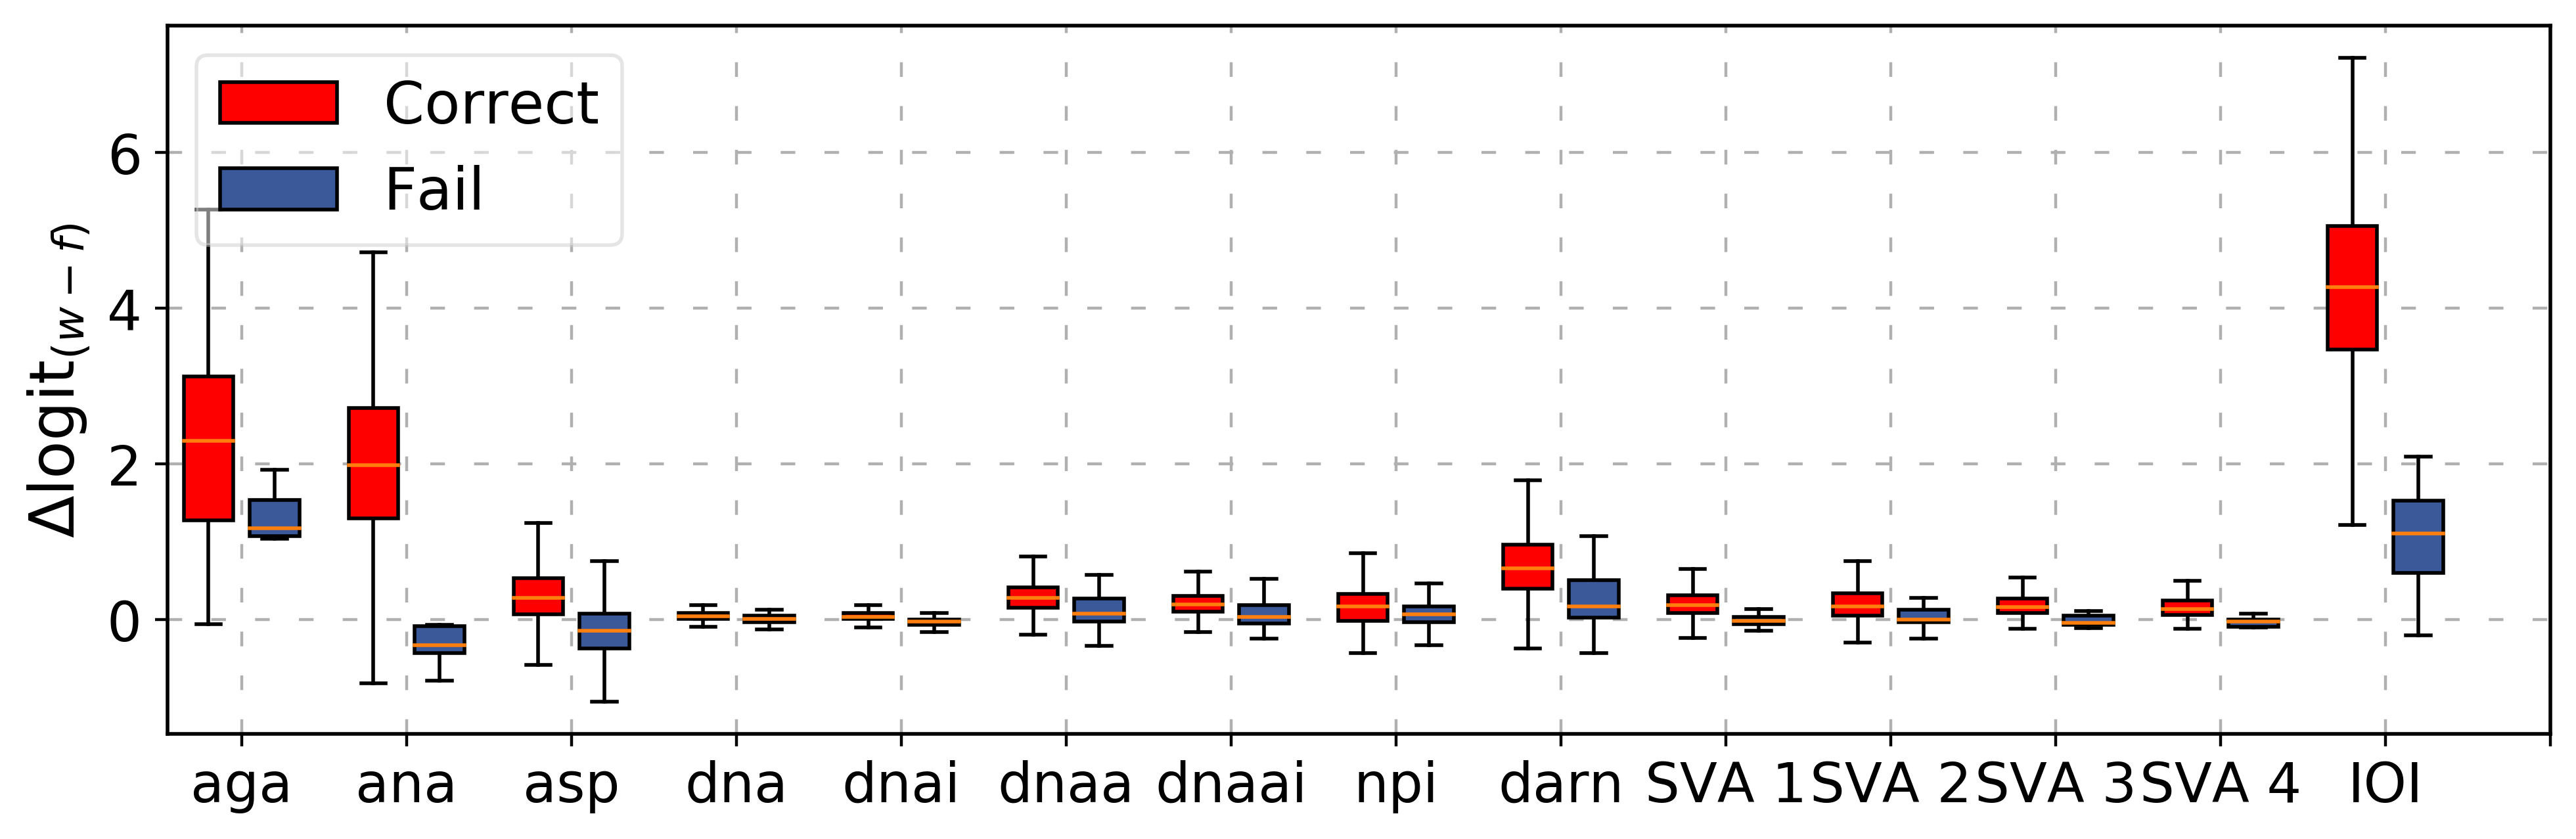

In [ ]:
from matplotlib.transforms import Affine2D
from src.utils import task_to_abbr
fig, ax = plt.subplots(figsize=(11.7,3.5),dpi=400)#figsize=(10,3)

data_a = dict_dicts['corrects']['logit_aff_x_j_alti']
data_b = dict_dicts['fails']['logit_aff_x_j_alti']

#trans = Affine2D().translate(trans_list[i], 0.0) + ax.transData

labels, data = data_a.keys(), data_a.values()
bpl = ax.boxplot(data_a.values(), positions=np.array(range(len(data_a)))*2.0-0.4, sym='', widths=0.6, patch_artist=True)
for patch in bpl['boxes']:
        patch.set(facecolor='r')
bpr = ax.boxplot(data_b.values(), positions=np.array(range(len(data_b)))*2.0+0.4, sym='', widths=0.6, patch_artist=True)
for patch in bpr['boxes']:
        patch.set(facecolor='#3b5998')    
#plt.violinplot(data,showmedians=True)
ax.legend([bpl["boxes"][0], bpr["boxes"][0]], ['Correct', 'Fail'],prop={'size': 16},framealpha=0.5,loc='upper left')
plt.xticks(range(0, len(labels)*2 + 1, 2), [task_to_abbr[label] for label in labels])
#ax.set_title(f'{dataset_2_ling_name[subset]}: {model_2_label[name_path]}', size=17)
#ax.set_xlabel('Layer', size=17)
ax.set_ylabel(r'$\Delta \mathrm{logit}_{(w-f)}$', size=17)
ax.grid(True, linestyle=(0, (5, 10)));


# Read results

In [ ]:
from src.utils import task_to_abbr, dataset_2_ling_name
metric = 'mrr'
dataset = 'ioi'

dataset_2_label = {'blimp' : 'BLiMP',
                    'sva': 'SVA',
                    'ioi': 'IOI',
                    'sva_1': 'SVA1',
                    'sva_2': 'SVA2',
                    'sva_3': 'SVA3',
                    'sva_4': 'SVA4'}

model_2_label = {'gpt2': 'GPT-2 Small',
                    'gpt2-large': 'GPT-2 Large',
                    'gpt2-xl': 'GPT-2 XL',
                    'facebook-opt-125m': 'OPT 125M',
                    'bigscience-bloom-560m': 'BLOOM 560M',
                    'bigscience-bloom-1b1': 'BLOOM 1B1'

}
labels = ['Random', 'Grad Norm', r'G$\times$I', 'Erasure', 'Logit', 'ALTI-Logit']
color = ['#82B366', '#6C8EBF','#D79B00','#5C5C5C', '#E9967A', '#C15252']

method_name_to_clean_name = {
    'random':'Random',
    'grad_norm_2' :'Grad Norm',
    'grad_inp_2' :r'G$\times$I',
    'erasure' : 'Erasure',
    'logit_aff_x_j': 'Logit',
    'logit_aff_x_j_alti': 'ALTI Logit'
}
if name_path == 'gpt2-xl':
    num_layers = 48
elif name_path == 'gpt2':
    num_layers = 12


In [ ]:
name_path = 'gpt2'
methods = ['erasure', 'logit_aff_x_j', 'logit_aff_x_j_alti', 'grad_norm_2', 'grad_inp_2', 'random']

df = pd.read_csv(f'./results/tables/all_datasets/{name_path}_{metric}.csv', index_col=0)[methods]
def change_index(dataset_):
    return task_to_abbr[dataset_]

df.index = df.index.map(lambda x: change_index(x))
df.to_csv(f'./results/paper_{name_path}.csv')

/home/usuaris/veu/javier.ferrando/anaconda3/envs/alti/lib/python3.7/site-packages/matplotlib/cbook/__init__.py:1402: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x[:, None]
/home/usuaris/veu/javier.ferrando/anaconda3/envs/alti/lib/python3.7/site-packages/matplotlib/axes/_base.py:278: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  y = y[:, np.newaxis]


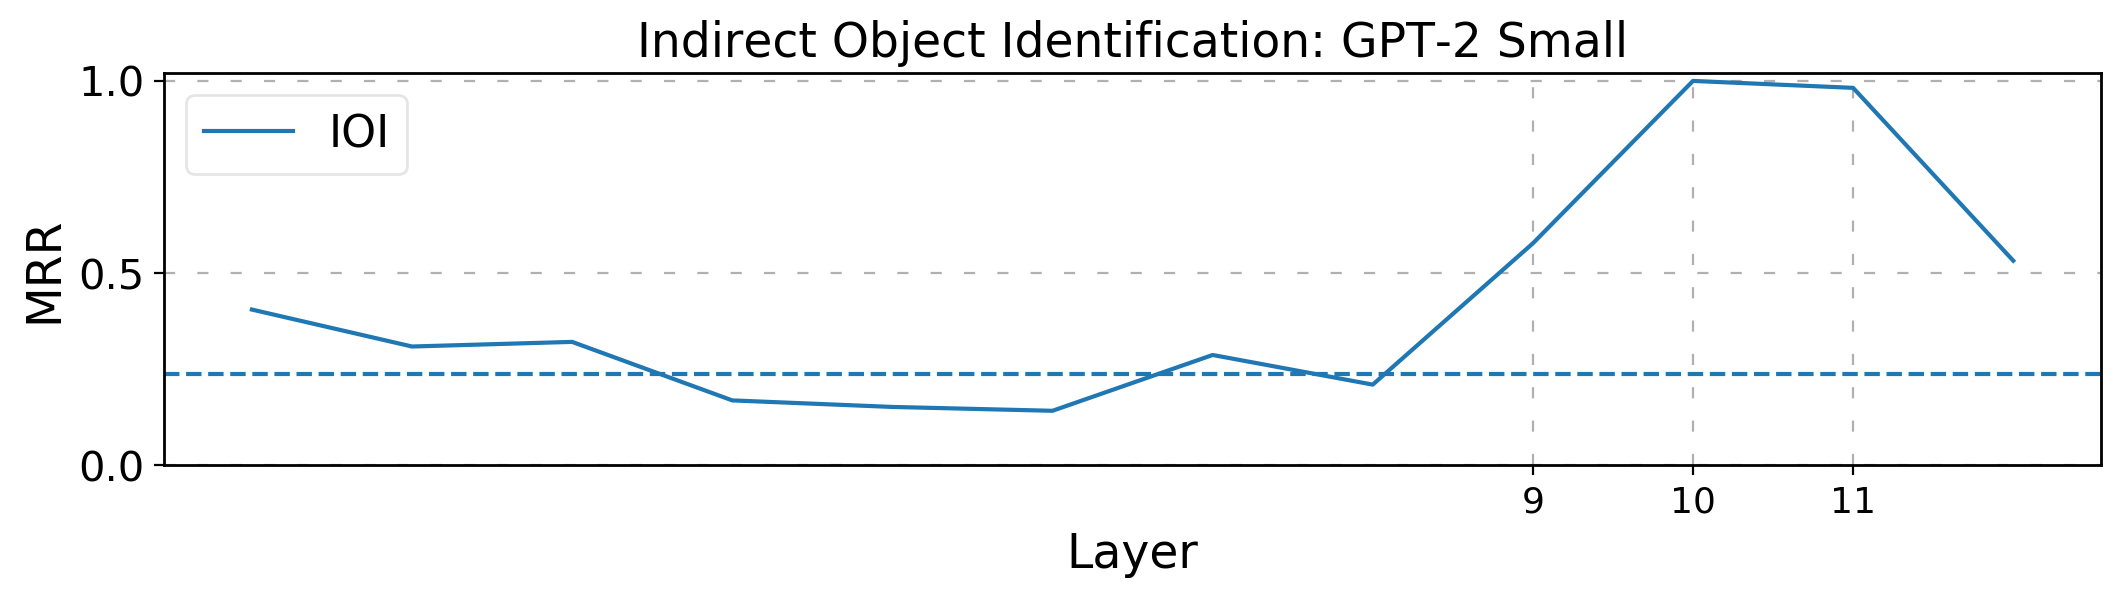

In [ ]:
fig, ax = plt.subplots(figsize =(12.5, 2.6),dpi=200)
from matplotlib.ticker import FormatStrFormatter

name_path = 'gpt2'
metric = 'mrr'


subsets = ['ioi']
method = 'logit_aff_x_j_alti'
#subsets_list = list(pd.read_csv(f'./results/{dataset}/layerwise_{metric}_{name_path}.csv')['Unnamed: 0'])
df_layers = pd.read_csv(f'./results/tables/all_datasets/{name_path}_{metric}.csv', index_col=0)[[f'{method}_layer_' + str(i) for i in range(num_layers)]+ ['random']]
df_layers = df_layers.transpose()
random_values = df_layers.loc['random']
#df.columns = subsets_list
random_vals = df_layers[subsets].loc['random']
df_layers = df_layers.drop('random')
for j, subset in enumerate(subsets):
    random_val = random_vals[subset]
    p = plt.plot(np.arange(1,num_layers+1), df_layers[subset], label = task_to_abbr[subset])
    color = p[0].get_color()
    plt.axhline(y=random_val, linestyle='--', c=color)

if 'anaphor_gender_agreement' in subsets:
    ax.set_ylim(0.5,1.09)
elif 'determiner_noun_agreement_1' in subsets:
    ax.set_ylim(0.35,1.2)
elif 'ioi' in subsets:
    ax.set_ylim(0.0,1.02)

if name_path == 'gpt2':
    k = 3
    size_x_ticks = 13
elif name_path == 'gpt2-xl':
    k = 8
    size_x_ticks = 10.5
top_k_layers = np.argpartition(np.array(df_layers[subset]), -k)[-k:]+1
ax.set_xticks(top_k_layers)
ax.set_xticklabels(top_k_layers, rotation=0, size=size_x_ticks)# np.arange(1,num_layers+1)

ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
ax.legend(prop={'size': 16},framealpha=0.5,loc='upper left')
ax.set_title(f'{dataset_2_ling_name[subset]}: {model_2_label[name_path]}', size=17)
ax.set_xlabel('Layer', size=17)
ax.set_ylabel('MRR', size=17)
ax.grid(True, linestyle=(0, (5, 10)));

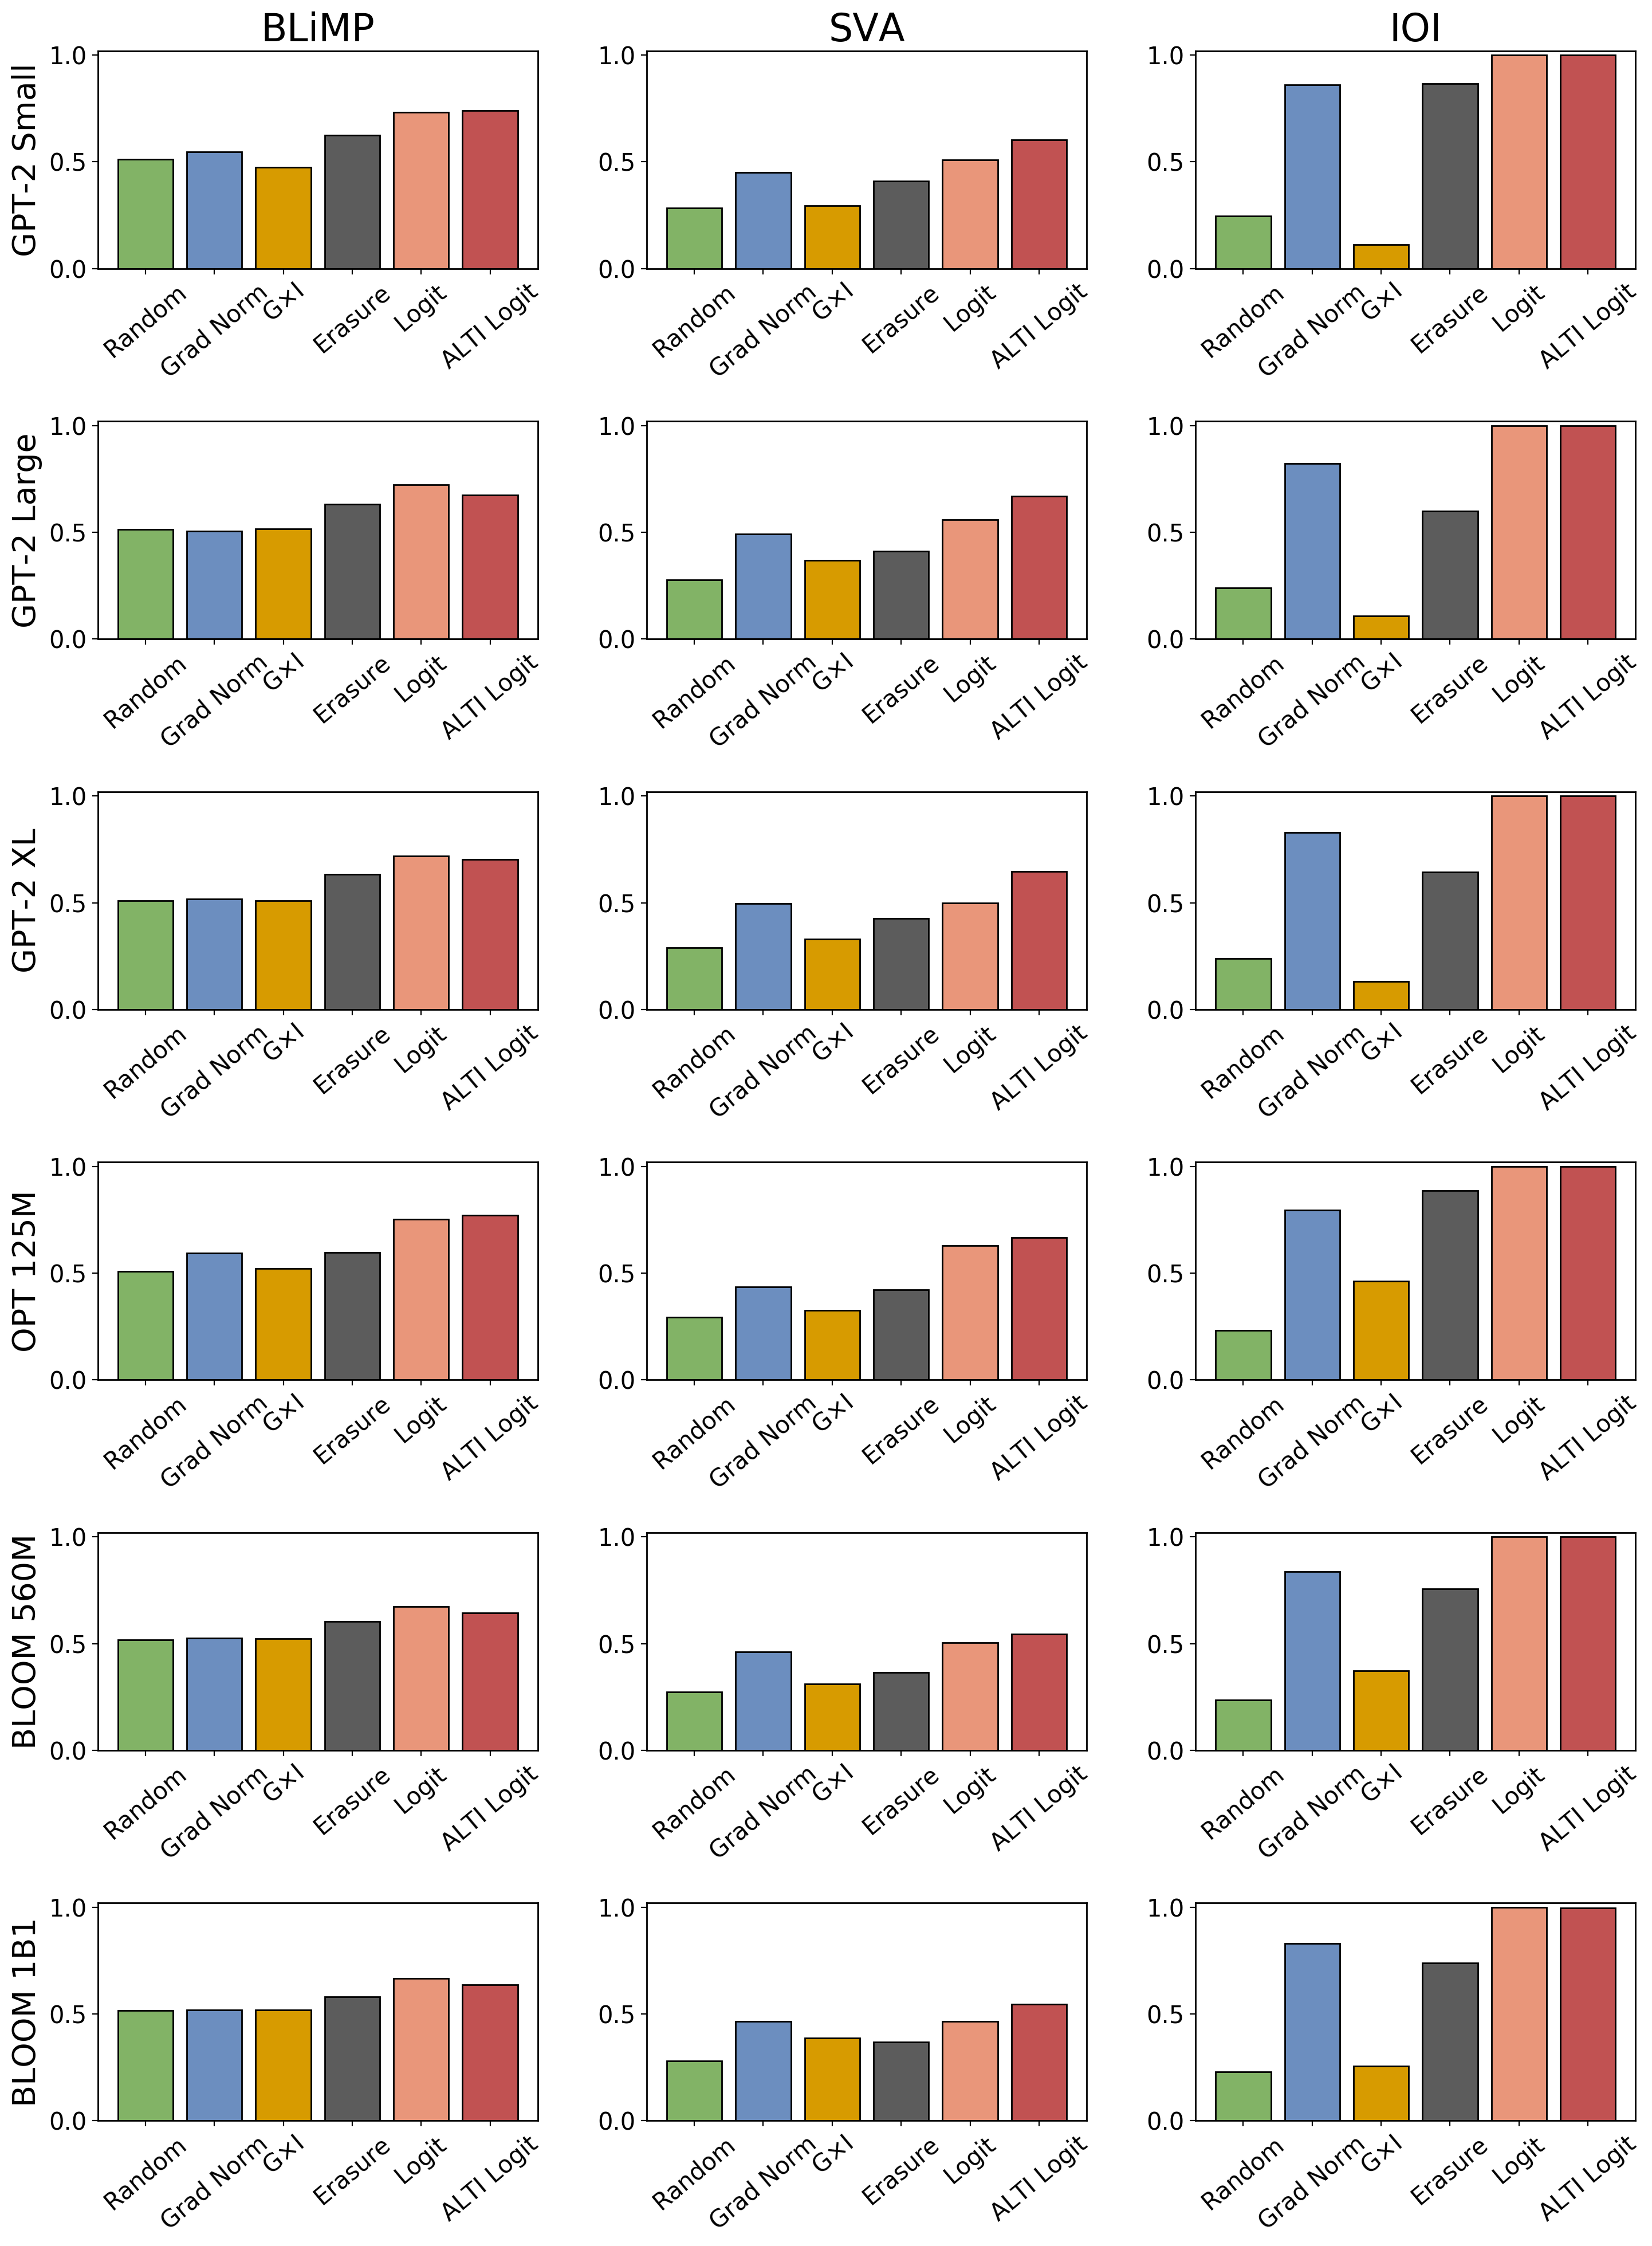

In [ ]:
col = 3
row = 6

fig, axs = plt.subplots(row, col,figsize=(15,20), dpi=200,sharey=False)

metric = 'mrr'
methods = ['random', 'grad_norm_2', 'grad_inp_2', 'erasure', 'logit_attn_full', 'logit_attn_full_alti']

for row_num, name_path in enumerate(['gpt2', 'gpt2-large', 'gpt2-xl', 'facebook-opt-125m', 'bigscience-bloom-560m', 'bigscience-bloom-1b1']):
    name_path = name_path.replace('/','-')
    for col_num, dataset in enumerate(['blimp', 'sva', 'ioi']):
        df = pd.read_csv(f'./results/tables/all_datasets/{name_path}_{metric}.csv', index_col=0)
        if dataset == 'blimp':
            df = df[~((df.index.str.contains("sva")|(df.index.str.contains("ioi"))))]
        else:
            df = df[df.index.str.contains(dataset)]
        df_mean = df[methods].mean()
        axs[row_num,col_num].bar(range(len(df_mean)),df_mean.values, color=color, edgecolor='black')
        axs[row_num,col_num].set_xticks(range(0,len(df_mean)))
        axs[row_num,col_num].set_xticklabels([method_name_to_clean_name[m] for m in methods], rotation=40)
        if metric == 'mrr':
            axs[row_num,col_num].set_ylim(0.0,1.02)
        elif metric == 'probes':
            if col_num == 0:
                max_height = 2.52
            elif col_num == 1:
                max_height = 8.02
            elif col_num == 2:
                max_height = 14.02
            #axs[row_num,col_num].set_yticks(np.arange(0,max_height,0.5))
            axs[row_num,col_num].set_ylim(0.0,max_height)
        if col_num == 0:
            axs[row_num,col_num].set_ylabel(model_2_label[name_path])
        if row_num == 0:
            axs[row_num,col_num].set_title(dataset_2_label[dataset])
fig.tight_layout()


In [ ]:
df_correct = pd.read_csv(f'./results/tables/all_datasets/correct_{name_path}_{metric}.csv', index_col=0)
df_fail = pd.read_csv(f'./results/tables/all_datasets/fail_{name_path}_{metric}.csv', index_col=0)

df_correct.mean() - df_fail.mean()

erasure                     0.196071
logit_attn_full             0.202857
logit_attn_full_alti        0.241929
logit_attn_full_mlp_alti    0.243500
logit_attn_simp             0.153071
logit_attn_simp_alti        0.192143
logit_attn_simp_mlp_alti    0.243500
grad_norm                   0.002286
grad_inp                   -0.015214
grad_norm_2                -0.002714
grad_inp_2                 -0.105143
random                      0.004000
dtype: float64

random                  0.512333
grad_norm_2             0.546444
grad_inp_2              0.475111
erasure                 0.625222
logit_attn_full         0.730667
logit_attn_full_alti    0.739111
dtype: float64

random                  0.28325
grad_norm_2             0.44900
grad_inp_2              0.29475
erasure                 0.40975
logit_attn_full         0.51025
logit_attn_full_alti    0.60400
dtype: float64

random                  0.245
grad_norm_2             0.860
grad_inp_2              0.111
erasure                 0.865
logit_attn_full         1.000
logit_attn_full_alti    1.000
dtype: float64

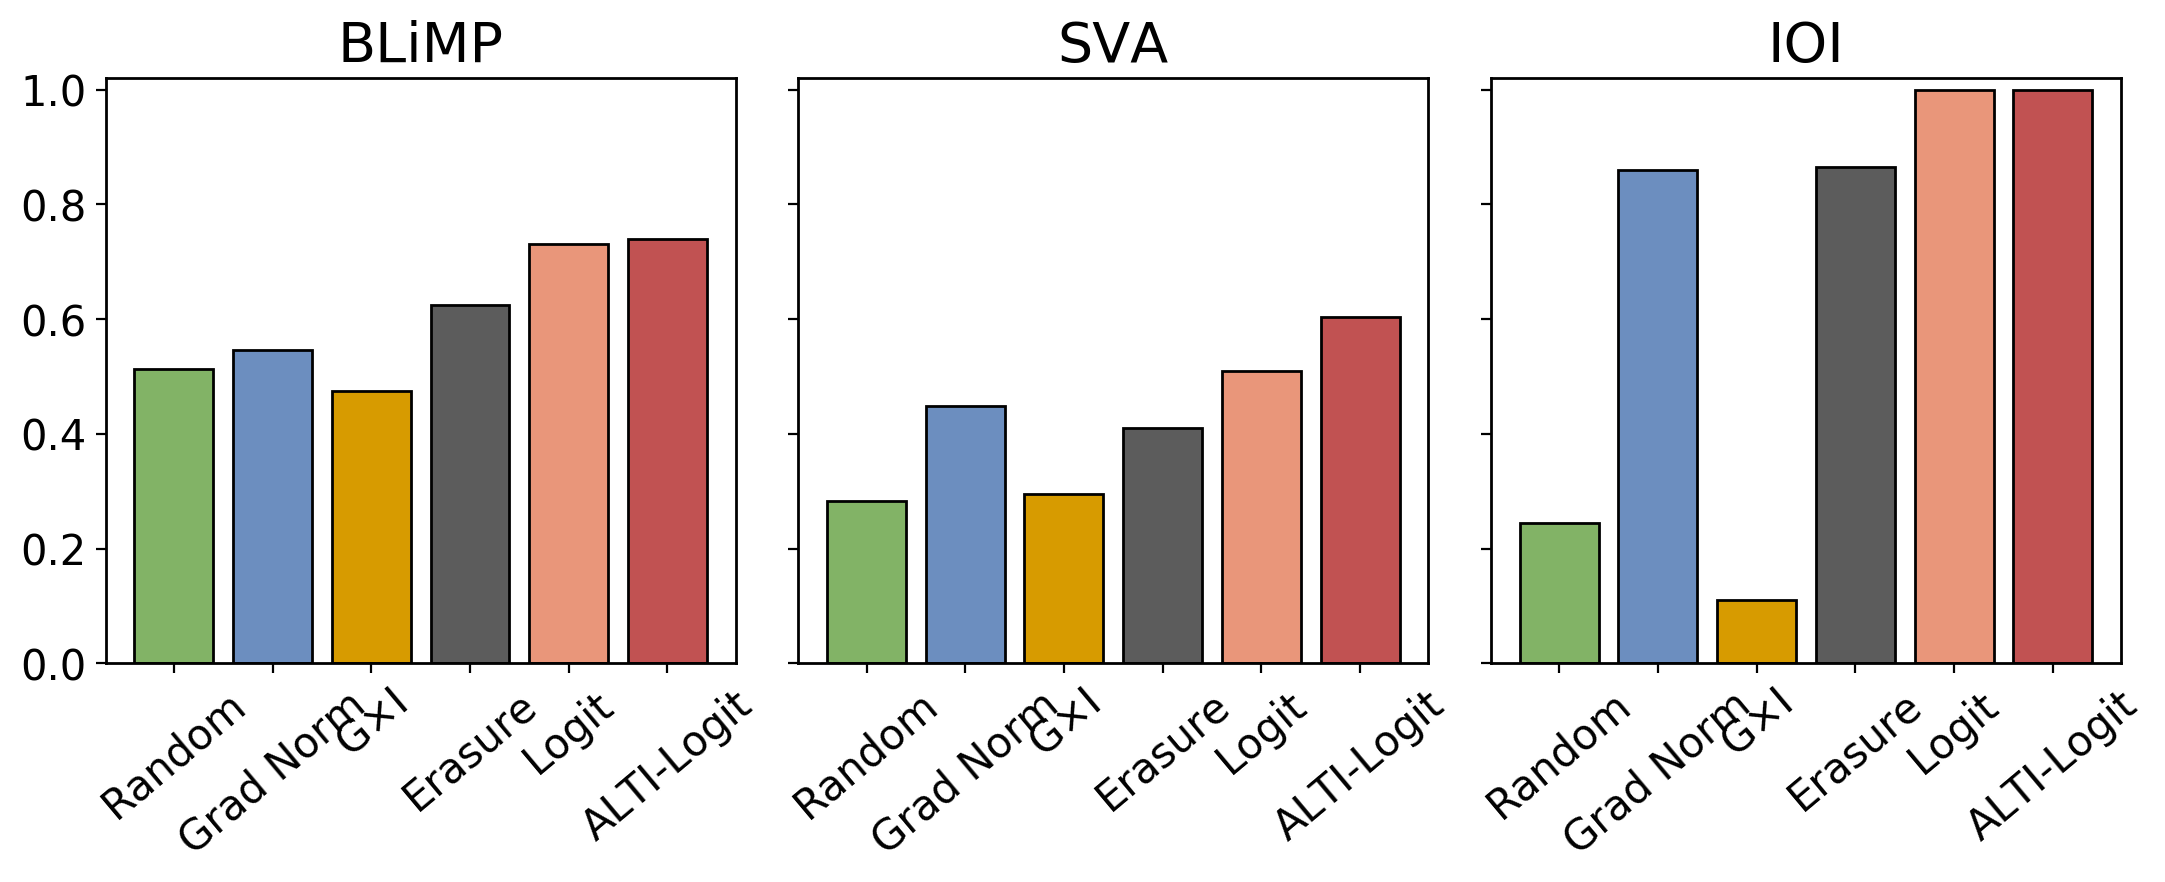

In [ ]:
col = 3
row = 1

fig, axs = plt.subplots(row, col,figsize=(13,3.8), dpi=200,sharey=True)
plt.subplots_adjust(wspace=0.1)
metric = 'mrr'
methods = ['random', 'grad_norm_2', 'grad_inp_2', 'erasure', 'logit_attn_full', 'logit_attn_full_alti']
for row_num, name_path in enumerate(['gpt2']):
    for col_num, dataset in enumerate(['blimp', 'sva', 'ioi']):
        df = pd.read_csv(f'./results/tables/all_datasets/{name_path}_{metric}.csv', index_col=0)
        #df = pd.read_csv(f'./results/tables/{dataset}/{name_path}_{metric}.csv', index_col=0)
        if dataset == 'blimp':
            df = df[~((df.index.str.contains("sva")|(df.index.str.contains("ioi"))))]
        else:
            df = df[df.index.str.contains(dataset)]
        df_mean = df[methods].mean()
        display(df_mean)
        axs[col_num].bar(range(len(df_mean)),df_mean.values, color=color, edgecolor='black')
        axs[col_num].set_xticks(range(0,len(df_mean)))
        axs[col_num].set_xticklabels(labels, rotation=40)
        if metric == 'mrr':
            axs[col_num].set_ylim(0.0,1.02)
        elif metric == 'probes':
            if col_num == 0:
                max_height = 2.02
            elif col_num == 1:
                max_height = 8.02
            elif col_num == 2:
                max_height = 10.02
            #axs[row_num,col_num].set_yticks(np.arange(0,max_height,0.5))
            axs[col_num].set_ylim(0.0,max_height)
        # if col_num == 0:
        #     axs[col_num].set_ylabel(model_2_label[name_path],fontsize=18)# model_2_label[name_path]
        if row_num == 0:
            axs[col_num].set_title(dataset_2_label[dataset],fontsize=20)
#fig.tight_layout()
